# Campanas de Gauss, matriz de covarianza y distancia de Mahalanobis

Cuaderno **didactico**, no es la actividad. Sirve para ver con graficos tres cosas que se explican mal con palabras:

1. Que es una campana de Gauss cuando pasa de una a dos dimensiones.
2. Que significan de verdad los cuatro numeros de una matriz de covarianza.
3. Por que la distancia de Mahalanobis mide algo distinto que la euclidiana, y por que eso es lo que separa a GMM de K-means.

Todos los datos son simulados a proposito: aqui se sabe la respuesta de antemano, que es justo lo que hace falta para entender el mecanismo.


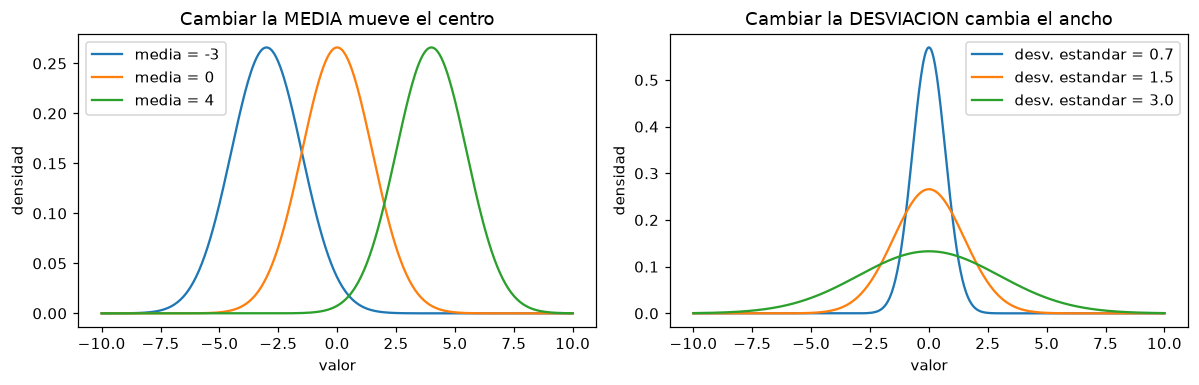

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from matplotlib.patches import Ellipse

rng = np.random.default_rng(7)
plt.rcParams['figure.dpi'] = 110

x = np.linspace(-10, 10, 500)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

for mu in [-3, 0, 4]:
    ax[0].plot(x, norm.pdf(x, mu, 1.5), label=f'media = {mu}')
ax[0].set_title('Cambiar la MEDIA mueve el centro')
ax[0].set_xlabel('valor'); ax[0].set_ylabel('densidad'); ax[0].legend()

for s in [0.7, 1.5, 3.0]:
    ax[1].plot(x, norm.pdf(x, 0, s), label=f'desv. estandar = {s}')
ax[1].set_title('Cambiar la DESVIACION cambia el ancho')
ax[1].set_xlabel('valor'); ax[1].set_ylabel('densidad'); ax[1].legend()

plt.tight_layout(); plt.show()


## De una dimension a dos

En 1D bastan dos numeros: **media** (donde esta el centro) y **desviacion estandar** (que tan ancha es).

En 2D el centro son dos numeros, uno por eje. Pero el ancho ya no es un numero: hay que decir cuan ancha es la campana **en cada direccion**, y ademas si los dos ejes estan relacionados entre si.

Eso es lo que guarda la **matriz de covarianza**. Abajo, la misma campana vista de tres formas: como superficie 3D, como mapa de densidad y como curvas de nivel. Las curvas de nivel son la vista que se usa siempre, porque muestran la forma sin estorbar.


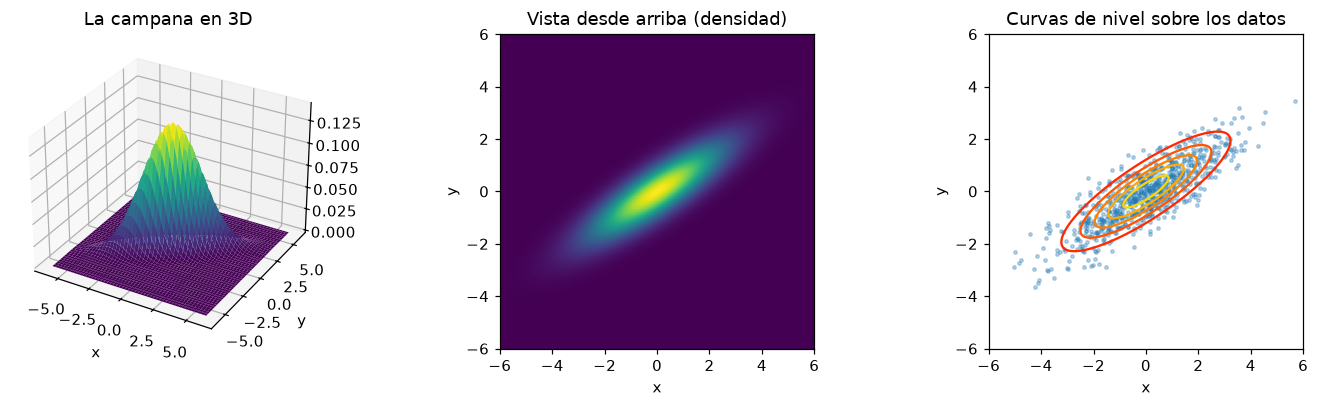

In [2]:
media = np.array([0, 0])
cov = np.array([[3.0, 1.8], [1.8, 1.5]])

g = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(g, g)
pos = np.dstack((X, Y))
Z = multivariate_normal(media, cov).pdf(pos)

fig = plt.figure(figsize=(13, 3.8))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', linewidth=0)
ax1.set_title('La campana en 3D')
ax1.set_xlabel('x'); ax1.set_ylabel('y')

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(Z, extent=[-6, 6, -6, 6], origin='lower', cmap='viridis')
ax2.set_title('Vista desde arriba (densidad)')
ax2.set_xlabel('x'); ax2.set_ylabel('y')

ax3 = fig.add_subplot(1, 3, 3)
muestras = rng.multivariate_normal(media, cov, 800)
ax3.scatter(muestras[:, 0], muestras[:, 1], s=5, alpha=0.3)
ax3.contour(X, Y, Z, levels=6, cmap='autumn')
ax3.set_title('Curvas de nivel sobre los datos')
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.set_xlim(-6, 6); ax3.set_ylim(-6, 6); ax3.set_aspect('equal')

plt.tight_layout(); plt.show()


## Los cuatro numeros de la matriz

```
        [ var(x)      cov(x,y) ]
  cov = [ cov(x,y)    var(y)   ]
```

- **Diagonal**: `var(x)` y `var(y)` son el ancho al cuadrado en cada eje. Numeros grandes, campana ancha en ese eje.
- **Fuera de la diagonal**: `cov(x,y)` es la **inclinacion**. Si vale cero, la elipse esta alineada con los ejes. Si es positiva, se inclina hacia arriba a la derecha. Si es negativa, hacia abajo.

La matriz es simetrica: `cov(x,y)` y `cov(y,x)` son el mismo numero, por eso aparece dos veces.

Los tres casos que `scikit-learn` llama `spherical`, `diag` y `full`:


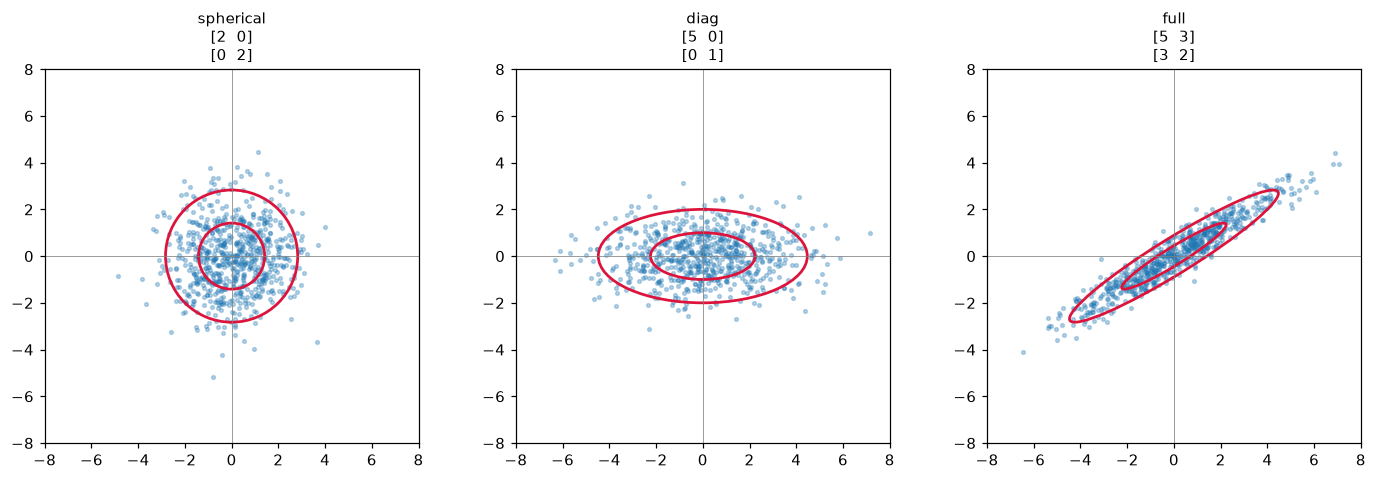

In [3]:
def dibujar_elipse(ax, media, cov, n_sigmas=(1, 2), color='crimson'):
    valores, vectores = np.linalg.eigh(cov)
    orden = valores.argsort()[::-1]
    valores, vectores = valores[orden], vectores[:, orden]
    angulo = np.degrees(np.arctan2(vectores[1, 0], vectores[0, 0]))
    for s in n_sigmas:
        ancho, alto = 2 * s * np.sqrt(valores)
        ax.add_patch(Ellipse(media, ancho, alto, angle=angulo,
                             fill=False, edgecolor=color, linewidth=1.8))
    return valores, vectores

casos = [
    ('spherical', np.array([[2.0, 0.0], [0.0, 2.0]])),
    ('diag', np.array([[5.0, 0.0], [0.0, 1.0]])),
    ('full', np.array([[5.0, 3.0], [3.0, 2.0]])),
]

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (nombre, C) in zip(ax, casos):
    pts = rng.multivariate_normal([0, 0], C, 700)
    a.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.3)
    dibujar_elipse(a, [0, 0], C)
    a.set_title(f"{nombre}\n[{C[0,0]:.0f}  {C[0,1]:.0f}]\n[{C[1,0]:.0f}  {C[1,1]:.0f}]", fontsize=10)
    a.set_xlim(-8, 8); a.set_ylim(-8, 8); a.set_aspect('equal')
    a.axhline(0, color='gray', linewidth=0.5); a.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout(); plt.show()


### El numero de fuera de la diagonal es la inclinacion

Para verlo aislado: se deja la diagonal fija y solo se mueve `cov(x,y)`. La elipse no cambia de tamano, gira.


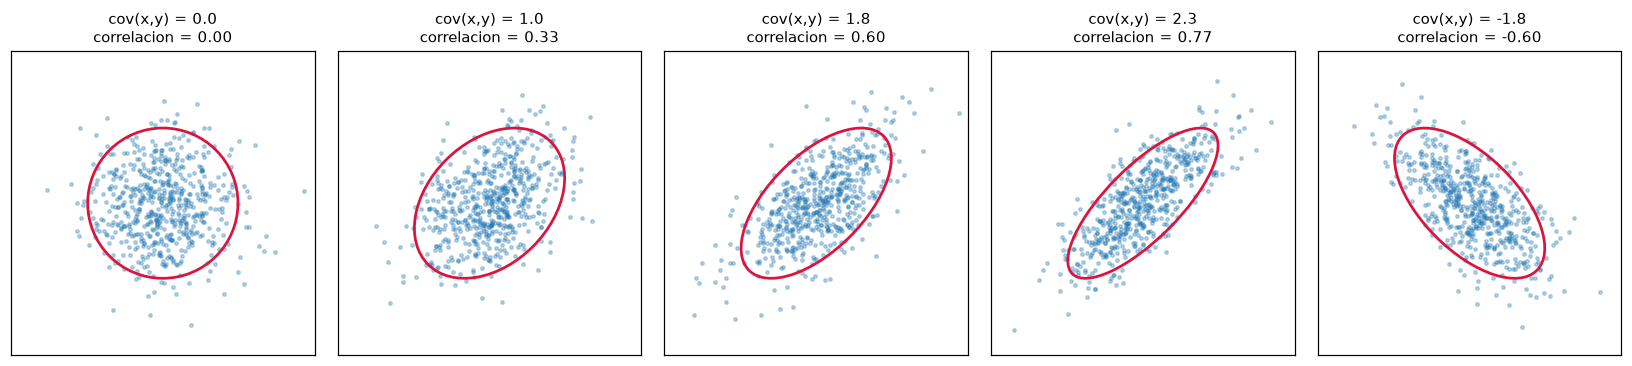

In [4]:
valores_cov = [0.0, 1.0, 1.8, 2.3, -1.8]

fig, ax = plt.subplots(1, len(valores_cov), figsize=(15, 3.2))
for a, c in zip(ax, valores_cov):
    C = np.array([[3.0, c], [c, 3.0]])
    pts = rng.multivariate_normal([0, 0], C, 600)
    a.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.3)
    dibujar_elipse(a, [0, 0], C, n_sigmas=(2,))
    correlacion = c / 3.0
    a.set_title(f'cov(x,y) = {c}\ncorrelacion = {correlacion:.2f}', fontsize=10)
    a.set_xlim(-7, 7); a.set_ylim(-7, 7); a.set_aspect('equal')
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()


## La clave: los ejes de la elipse salen de la matriz

Aqui es donde la matriz de covarianza deja de ser cuatro numeros sueltos y pasa a significar algo geometrico.

Toda matriz de covarianza se puede descomponer en **autovectores** y **autovalores**:

- los **autovectores** son las **direcciones** de los ejes de la elipse
- los **autovalores** son la **varianza a lo largo de cada uno de esos ejes**, y su raiz cuadrada es el largo del semieje

Dicho de otro modo: la matriz esta diciendo *"mis datos se estiran esta cantidad en esta direccion, y esta otra cantidad en esta otra direccion perpendicular"*. La inclinacion aparece porque esas direcciones no coinciden con los ejes x e y.

Y aqui esta la conexion con PCA que conviene ver ahora: **PCA es exactamente esto**. Los componentes principales son los autovectores de la matriz de covarianza de los datos, ordenados por autovalor. PC1 es la flecha larga del dibujo de abajo.


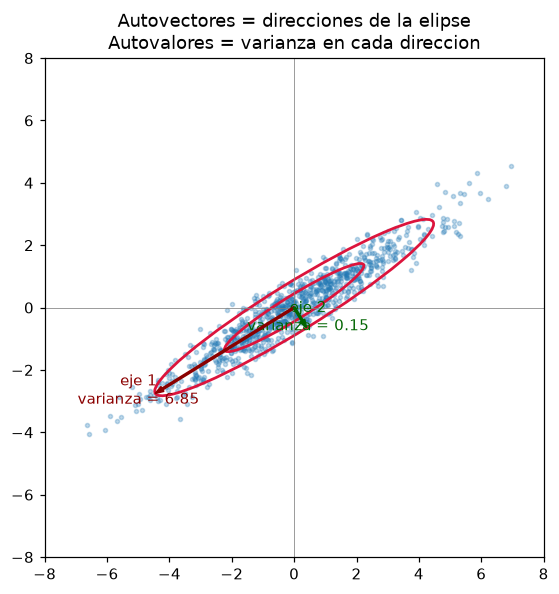

Matriz de covarianza:
[[5. 3.]
 [3. 2.]]

Autovalores (varianza por eje): [6.854 0.146]
Autovectores (direcciones, en columnas):
[[-0.851  0.526]
 [-0.526 -0.851]]

El primer eje concentra el 97.9% de la varianza total.


In [5]:
C = np.array([[5.0, 3.0], [3.0, 2.0]])
pts = rng.multivariate_normal([0, 0], C, 900)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(pts[:, 0], pts[:, 1], s=7, alpha=0.28)
valores, vectores = dibujar_elipse(ax, [0, 0], C, n_sigmas=(1, 2))

colores = ['darkred', 'darkgreen']
for k in range(2):
    v = vectores[:, k] * np.sqrt(valores[k]) * 2
    ax.arrow(0, 0, v[0], v[1], width=0.06, color=colores[k], length_includes_head=True, zorder=5)
    ax.text(v[0] * 1.12, v[1] * 1.12, f'eje {k+1}\nvarianza = {valores[k]:.2f}',
            color=colores[k], fontsize=10, ha='center')

ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title('Autovectores = direcciones de la elipse\nAutovalores = varianza en cada direccion')
plt.tight_layout(); plt.show()

print('Matriz de covarianza:'); print(C)
print(); print('Autovalores (varianza por eje):', np.round(valores, 3))
print('Autovectores (direcciones, en columnas):'); print(np.round(vectores, 3))
print(); print(f'El primer eje concentra el {100*valores[0]/valores.sum():.1f}% de la varianza total.')


## Mahalanobis: la misma distancia, medida con la regla del cluster

Un cluster alargado. Dos puntos, ambos exactamente a la **misma distancia euclidiana** del centro: uno desplazado a lo largo del eje largo, otro a lo ancho.

Para la distancia euclidiana son intercambiables. Para el cluster no lo son en absoluto: uno cae dentro de la nube y el otro queda claramente fuera.

Las curvas grises son las lineas de igual distancia **euclidiana**: circulos. Las curvas rojas son las de igual distancia **de Mahalanobis**: elipses con la forma del propio cluster.


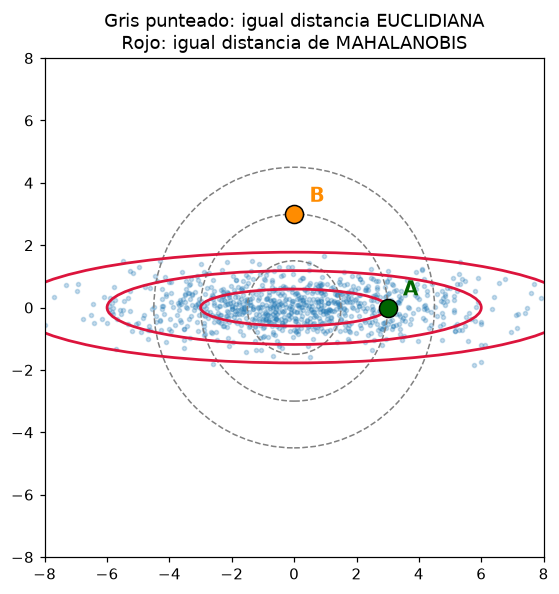

A (a lo largo)     euclidiana = 3.0    mahalanobis = 1.0
B (a lo ancho)     euclidiana = 3.0    mahalanobis = 5.07

Misma distancia euclidiana. En unidades del propio cluster, B esta cinco veces mas lejos que A.


In [6]:
C_larga = np.array([[9.0, 0.0], [0.0, 0.35]])
centro = np.array([0.0, 0.0])
pts = rng.multivariate_normal(centro, C_larga, 900)

p_largo = np.array([3.0, 0.0])
p_ancho = np.array([0.0, 3.0])

inv = np.linalg.inv(C_larga)
def mahalanobis(p):
    d = p - centro
    return float(np.sqrt(d @ inv @ d))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(pts[:, 0], pts[:, 1], s=7, alpha=0.25)

for radio in [1.5, 3.0, 4.5]:
    ax.add_patch(plt.Circle(centro, radio, fill=False, edgecolor='gray',
                            linestyle='--', linewidth=1))
dibujar_elipse(ax, centro, C_larga, n_sigmas=(1, 2, 3))

for p, nombre, color in [(p_largo, 'A', 'darkgreen'), (p_ancho, 'B', 'darkorange')]:
    ax.scatter(*p, s=140, color=color, zorder=6, edgecolor='black')
    ax.annotate(nombre, p, textcoords='offset points', xytext=(10, 8),
                fontsize=13, weight='bold', color=color)

ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_aspect('equal')
ax.set_title('Gris punteado: igual distancia EUCLIDIANA\nRojo: igual distancia de MAHALANOBIS')
plt.tight_layout(); plt.show()

resultados = []
for p, nombre in [(p_largo, 'A (a lo largo)'), (p_ancho, 'B (a lo ancho)')]:
    resultados.append({
        'punto': nombre,
        'euclidiana': round(float(np.linalg.norm(p - centro)), 2),
        'mahalanobis': round(mahalanobis(p), 2),
    })
for r in resultados:
    print(f"{r['punto']:<18} euclidiana = {r['euclidiana']:<6} mahalanobis = {r['mahalanobis']}")
print()
print('Misma distancia euclidiana. En unidades del propio cluster, B esta cinco veces mas lejos que A.')


### Otra forma de verlo: deformar el espacio hasta que el cluster sea redondo

Mahalanobis se puede entender sin formulas: es la distancia euclidiana **medida despues de estirar el espacio hasta que el cluster quede esferico**. La matriz de covarianza es la que dice como deshacer el estiramiento.

A la izquierda, el espacio original. A la derecha, el mismo espacio ya corregido. Fijate en que los dos puntos, que antes parecian equidistantes, dejan de parecerlo.


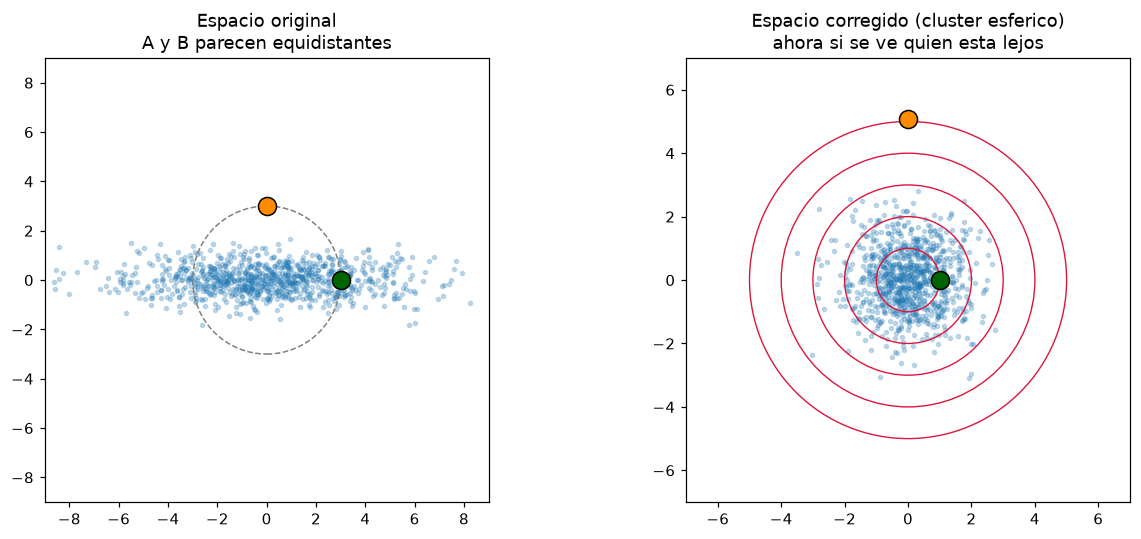

A: a 1.00 del centro en el espacio corregido
B: a 5.07 del centro en el espacio corregido

Esos dos numeros son exactamente las distancias de Mahalanobis del grafico anterior.


In [7]:
valores_l, vectores_l = np.linalg.eigh(C_larga)
W = vectores_l @ np.diag(1.0 / np.sqrt(valores_l)) @ vectores_l.T

pts_w = (pts - centro) @ W.T
p_largo_w = (p_largo - centro) @ W.T
p_ancho_w = (p_ancho - centro) @ W.T

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(pts[:, 0], pts[:, 1], s=7, alpha=0.25)
ax[0].scatter(*p_largo, s=140, color='darkgreen', edgecolor='black', zorder=6)
ax[0].scatter(*p_ancho, s=140, color='darkorange', edgecolor='black', zorder=6)
ax[0].add_patch(plt.Circle(centro, 3.0, fill=False, edgecolor='gray', linestyle='--'))
ax[0].set_xlim(-9, 9); ax[0].set_ylim(-9, 9); ax[0].set_aspect('equal')
ax[0].set_title('Espacio original\nA y B parecen equidistantes')

ax[1].scatter(pts_w[:, 0], pts_w[:, 1], s=7, alpha=0.25)
ax[1].scatter(*p_largo_w, s=140, color='darkgreen', edgecolor='black', zorder=6)
ax[1].scatter(*p_ancho_w, s=140, color='darkorange', edgecolor='black', zorder=6)
for radio in [1, 2, 3, 4, 5]:
    ax[1].add_patch(plt.Circle([0, 0], radio, fill=False, edgecolor='crimson', linewidth=0.9))
ax[1].set_xlim(-7, 7); ax[1].set_ylim(-7, 7); ax[1].set_aspect('equal')
ax[1].set_title('Espacio corregido (cluster esferico)\nahora si se ve quien esta lejos')

plt.tight_layout(); plt.show()

print(f'A: a {np.linalg.norm(p_largo_w):.2f} del centro en el espacio corregido')
print(f'B: a {np.linalg.norm(p_ancho_w):.2f} del centro en el espacio corregido')
print()
print('Esos dos numeros son exactamente las distancias de Mahalanobis del grafico anterior.')


## La "mezcla" de Mezcla Gaussiana

Hasta aqui, una sola campana. La **mezcla** asume que los datos salieron de **varias campanas superpuestas**, cada una con su peso: por ejemplo 50% de los puntos de la campana A, 30% de la B y 20% de la C.

Abajo, a la izquierda, se generan datos exactamente asi y se ve de que campana salio cada punto. A la derecha, lo unico que el algoritmo recibe: la nube, sin colores. Su trabajo es reconstruir las tres campanas.


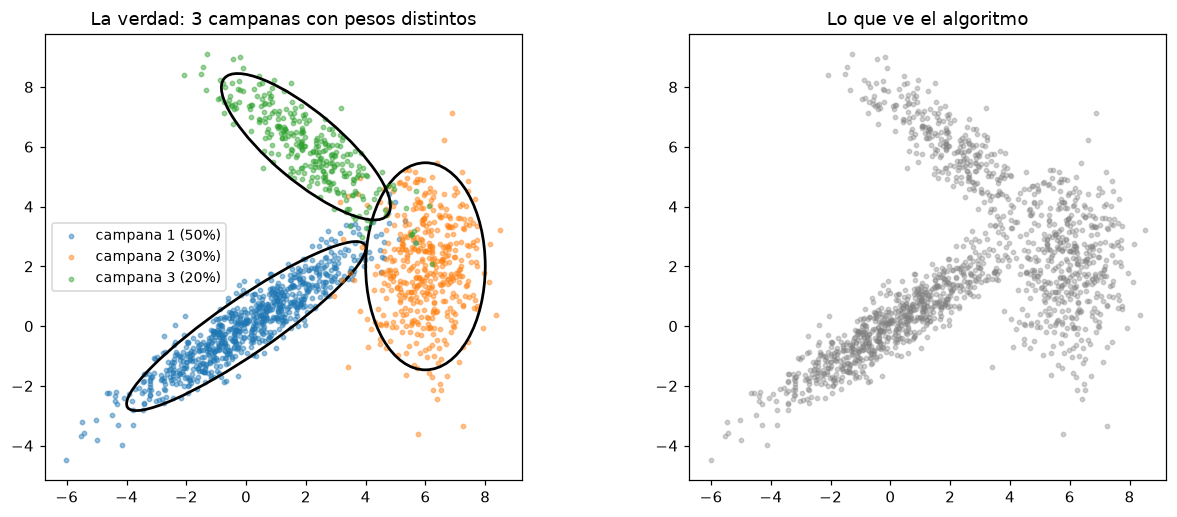

In [8]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

medias_reales = [np.array([0, 0]), np.array([6, 2]), np.array([2, 6])]
covs_reales = [np.array([[4.0, 2.6], [2.6, 2.0]]),
               np.array([[1.0, 0.0], [0.0, 3.0]]),
               np.array([[2.0, -1.4], [-1.4, 1.5]])]
pesos_reales = [0.5, 0.3, 0.2]
n_total = 1500

etiquetas_reales = rng.choice(3, size=n_total, p=pesos_reales)
datos = np.vstack([rng.multivariate_normal(medias_reales[k], covs_reales[k])
                   for k in etiquetas_reales])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for k in range(3):
    m = etiquetas_reales == k
    ax[0].scatter(datos[m, 0], datos[m, 1], s=8, alpha=0.45, label=f'campana {k+1} ({pesos_reales[k]:.0%})')
    dibujar_elipse(ax[0], medias_reales[k], covs_reales[k], n_sigmas=(2,), color='black')
ax[0].legend(fontsize=9); ax[0].set_title('La verdad: 3 campanas con pesos distintos')
ax[0].set_aspect('equal')

ax[1].scatter(datos[:, 0], datos[:, 1], s=8, alpha=0.35, color='gray')
ax[1].set_title('Lo que ve el algoritmo'); ax[1].set_aspect('equal')

plt.tight_layout(); plt.show()


### Que recupera GMM, y que significa la pertenencia blanda

GMM estima las tres medias, las tres covarianzas y los tres pesos. Y para cada punto no devuelve una etiqueta sino un **vector de responsabilidades**: cuanto pertenece a cada campana.

En el grafico de la derecha el color de cada punto mezcla los tres colores segun sus responsabilidades. Los puntos del centro de cada grupo salen de color puro; los de las zonas de solape salen mezclados. **Esa ambiguedad es informacion que K-means tira a la basura.**


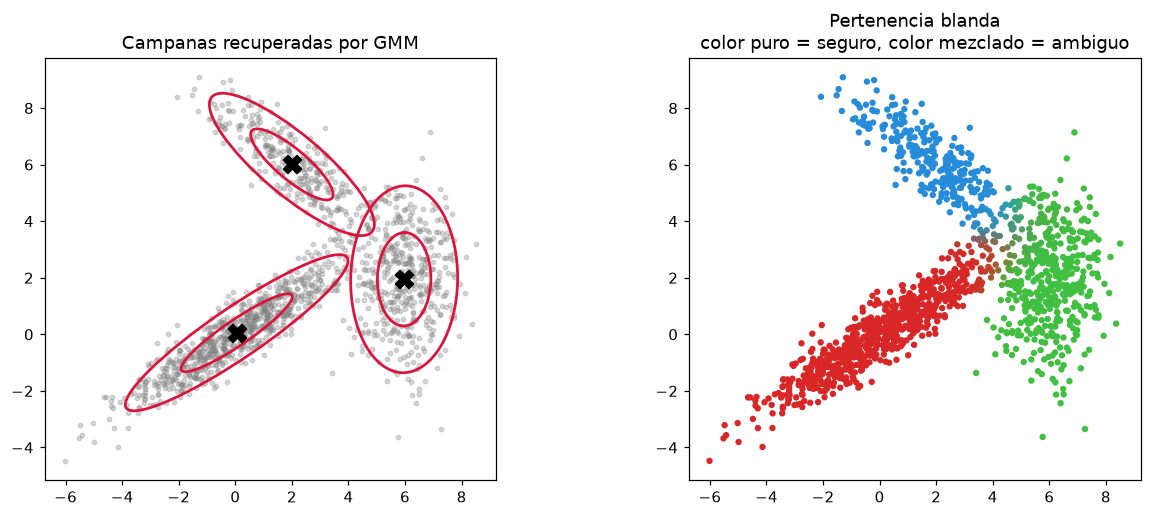

Pesos reales:       ['0.50', '0.30', '0.20']
Pesos estimados:    ['0.50', '0.30', '0.19']

Puntos asignados con mas de 95% de certeza: 1352 de 1500
Puntos ambiguos (ninguna campana supera 70%): 41


In [9]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(datos)
resp = gmm.predict_proba(datos)

base = np.array([[0.85, 0.15, 0.15], [0.15, 0.55, 0.85], [0.25, 0.75, 0.25]])
colores_mezcla = np.clip(resp @ base, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

ax[0].scatter(datos[:, 0], datos[:, 1], s=8, alpha=0.3, color='gray')
for k in range(3):
    dibujar_elipse(ax[0], gmm.means_[k], gmm.covariances_[k], n_sigmas=(1, 2), color='crimson')
    ax[0].scatter(*gmm.means_[k], marker='X', s=140, color='black', zorder=6)
ax[0].set_title('Campanas recuperadas por GMM'); ax[0].set_aspect('equal')

ax[1].scatter(datos[:, 0], datos[:, 1], s=10, c=colores_mezcla)
ax[1].set_title('Pertenencia blanda\ncolor puro = seguro, color mezclado = ambiguo')
ax[1].set_aspect('equal')

plt.tight_layout(); plt.show()

print('Pesos reales:      ', [f'{p:.2f}' for p in pesos_reales])
print('Pesos estimados:   ', [f'{p:.2f}' for p in sorted(gmm.weights_, reverse=True)])
print()
maxima = resp.max(axis=1)
print(f'Puntos asignados con mas de 95% de certeza: {(maxima > 0.95).sum()} de {len(datos)}')
print(f'Puntos ambiguos (ninguna campana supera 70%): {(maxima < 0.70).sum()}')


## Donde se rompe K-means

El caso decisivo: dos grupos reales alargados y en diagonal. K-means solo puede cortar con una recta perpendicular a la linea que une sus centroides, asi que parte los grupos por donde no debe. GMM ajusta una covarianza por componente y sigue la forma real.

Es el mismo dataset y el mismo numero de grupos. Lo unico que cambia es el supuesto sobre la forma.


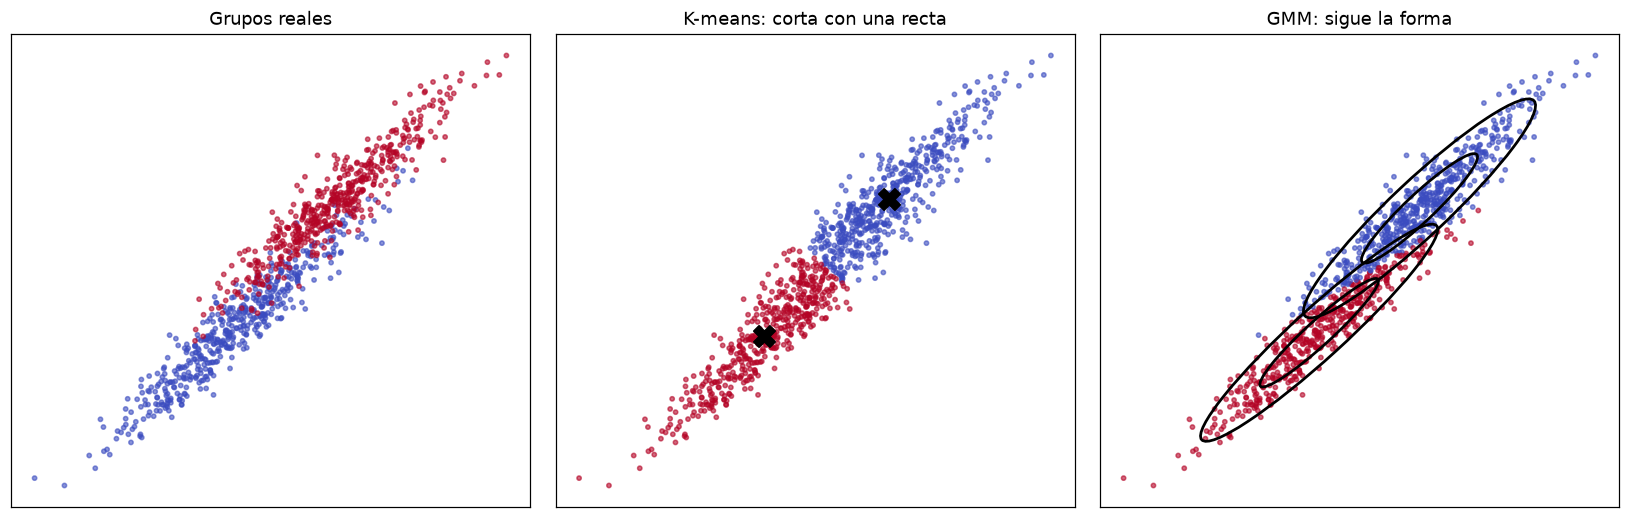

Coincidencia con los grupos reales  ->  K-means: 84.7%   GMM: 90.6%


In [10]:
C_diag = np.array([[6.0, 5.2], [5.2, 5.0]])
grupo_a = rng.multivariate_normal([-2, -2], C_diag, 500)
grupo_b = rng.multivariate_normal([2, 3], C_diag, 500)
X2 = np.vstack([grupo_a, grupo_b])
verdad = np.r_[np.zeros(500), np.ones(500)]

km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X2)
gm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))

ax[0].scatter(X2[:, 0], X2[:, 1], c=verdad, s=8, cmap='coolwarm', alpha=0.6)
ax[0].set_title('Grupos reales')

ax[1].scatter(X2[:, 0], X2[:, 1], c=km.labels_, s=8, cmap='coolwarm', alpha=0.6)
ax[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
              marker='X', s=200, color='black', zorder=6)
ax[1].set_title('K-means: corta con una recta')

ax[2].scatter(X2[:, 0], X2[:, 1], c=gm.predict(X2), s=8, cmap='coolwarm', alpha=0.6)
for k in range(2):
    dibujar_elipse(ax[2], gm.means_[k], gm.covariances_[k], n_sigmas=(1, 2), color='black')
ax[2].set_title('GMM: sigue la forma')

for a in ax:
    a.set_aspect('equal'); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

def acierto(pred):
    return max((pred == verdad).mean(), (pred != verdad).mean())

print(f'Coincidencia con los grupos reales  ->  K-means: {acierto(km.labels_):.1%}   GMM: {acierto(gm.predict(X2)):.1%}')


## Leer una matriz sin dibujarla

Ejercicio: `[[9, 6], [6, 5]]`. Tres preguntas que se responden con aritmetica sencilla, antes de graficar nada.

**Que tan inclinada esta.** El numero de fuera de la diagonal no se lee solo: se compara contra la diagonal. La correlacion es `cov(x,y) / sqrt(var(x)*var(y))`, aqui `6 / sqrt(9*5) = 0.89`. Cerca de 1, asi que la inclinacion es fuerte.

**Hacia donde apunta.** El eje largo sale de los autovectores. La cuenta rapida: como `var(x)=9` es mayor que `var(y)=5`, la elipse se estira mas en horizontal que en vertical, y con covarianza positiva se inclina hacia arriba a la derecha. Queda en diagonal, mas cerca de la horizontal que de la vertical.

**Que tan alargada es.** Los autovalores dan la varianza en cada eje. La relacion entre los semiejes es la raiz de su cociente.


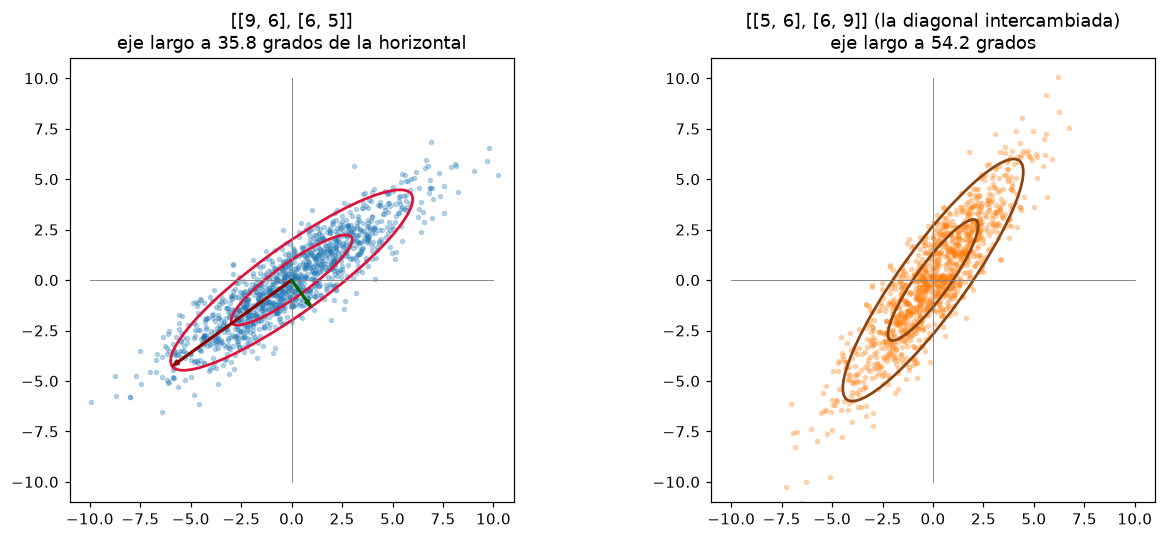

autovalores:            [13.325  0.675]
semiejes:               [3.65  0.822]
relacion largo/ancho:   4.44 a 1
correlacion:            0.894
varianza en el eje largo: 95.2%


In [11]:
C_ej = np.array([[9.0, 6.0], [6.0, 5.0]])
pts_ej = rng.multivariate_normal([0, 0], C_ej, 1200)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(pts_ej[:, 0], pts_ej[:, 1], s=7, alpha=0.28)
val_ej, vec_ej = dibujar_elipse(ax[0], [0, 0], C_ej, n_sigmas=(1, 2))
for k, color in enumerate(['darkred', 'darkgreen']):
    v = vec_ej[:, k] * np.sqrt(val_ej[k]) * 2
    ax[0].arrow(0, 0, v[0], v[1], width=0.08, color=color, length_includes_head=True, zorder=6)
angulo = np.degrees(np.arctan2(vec_ej[1, 0], vec_ej[0, 0])) % 180
ax[0].plot([-10, 10], [0, 0], color='gray', linewidth=0.6)
ax[0].plot([0, 0], [-10, 10], color='gray', linewidth=0.6)
ax[0].set_xlim(-11, 11); ax[0].set_ylim(-11, 11); ax[0].set_aspect('equal')
ax[0].set_title(f'[[9, 6], [6, 5]]\neje largo a {angulo:.1f} grados de la horizontal')

C_vertical = np.array([[5.0, 6.0], [6.0, 9.0]])
pts_v = rng.multivariate_normal([0, 0], C_vertical, 1200)
ax[1].scatter(pts_v[:, 0], pts_v[:, 1], s=7, alpha=0.28, color='tab:orange')
val_v, vec_v = dibujar_elipse(ax[1], [0, 0], C_vertical, n_sigmas=(1, 2), color='saddlebrown')
ang_v = np.degrees(np.arctan2(vec_v[1, 0], vec_v[0, 0])) % 180
ax[1].plot([-10, 10], [0, 0], color='gray', linewidth=0.6)
ax[1].plot([0, 0], [-10, 10], color='gray', linewidth=0.6)
ax[1].set_xlim(-11, 11); ax[1].set_ylim(-11, 11); ax[1].set_aspect('equal')
ax[1].set_title(f'[[5, 6], [6, 9]] (la diagonal intercambiada)\neje largo a {ang_v:.1f} grados')

plt.tight_layout(); plt.show()

print(f'autovalores:            {np.round(val_ej, 3)}')
print(f'semiejes:               {np.round(np.sqrt(val_ej), 3)}')
print(f'relacion largo/ancho:   {np.sqrt(val_ej[0]/val_ej[1]):.2f} a 1')
print(f'correlacion:            {6/np.sqrt(9*5):.3f}')
print(f'varianza en el eje largo: {100*val_ej[0]/val_ej.sum():.1f}%')
